In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

sales_data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', index_col=0)

# Exercise 1
### Visualize data as a heatmap and in another way of your choice.

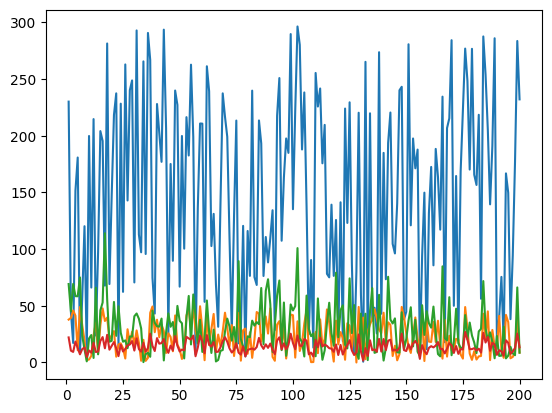

In [3]:
plt.plot(sales_data)

# Exercise 2
### a) Fit a simple linear regression model of every advertisement medium and print their summaries. (You should also try to understand them.)
### Hint: Don't forget to split the data into training and test sets!
### b) Fit a tviple linear regression model and print the summary

In [4]:
TV = "TV"
NEWSPAPER = "newspaper"
RADIO = "radio"
SALES = "sales"

#TV
X = sm.add_constant(sales_data[TV])
Y = sales_data[SALES]

tv_x_train, tv_x_test, tv_y_train, tv_y_test = train_test_split(
    X, Y, test_size= .2
)

tv_lm = sm.OLS(tv_y_train, tv_x_train).fit()
print(tv_lm.summary())

#Radio
X = sm.add_constant(sales_data[RADIO])
Y = sales_data[SALES]

radio_x_train, radio_x_test, radio_y_train, radio_y_test = train_test_split(
    X, Y, test_size= .2
)

radio_lm = sm.OLS(radio_y_train, radio_x_train).fit()
print(radio_lm.summary())

#News
X = sm.add_constant(sales_data[NEWSPAPER])
Y = sales_data[SALES]

news_x_train, news_x_test, news_y_train, news_y_test = train_test_split(
    X, Y, test_size= .2
)

news_lm = sm.OLS(news_y_train, news_x_train).fit()
print(news_lm.summary())





                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     246.7
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.39e-34
Time:                        21:21:51   Log-Likelihood:                -410.67
No. Observations:                 160   AIC:                             825.3
Df Residuals:                     158   BIC:                             831.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1468      0.484     14.773      0.0

In [5]:
#b
x = sales_data[[TV, RADIO, NEWSPAPER]]
y = sales_data[SALES]

x = sm.add_constant(x)

mult_x_train, mult_x_test , mult_y_train, mult_y_test = train_test_split(
    x, y, test_size=.2
)


mult_lm = sm.OLS(mult_y_train, mult_x_train).fit()

print(mult_lm.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     448.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.92e-76
Time:                        21:21:51   Log-Likelihood:                -311.86
No. Observations:                 160   AIC:                             631.7
Df Residuals:                     156   BIC:                             644.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6866      0.362      7.432      0.0

# Exercise 3
### a) Visualize any one of the simple linear regression models and the multiple linear regression model as plots

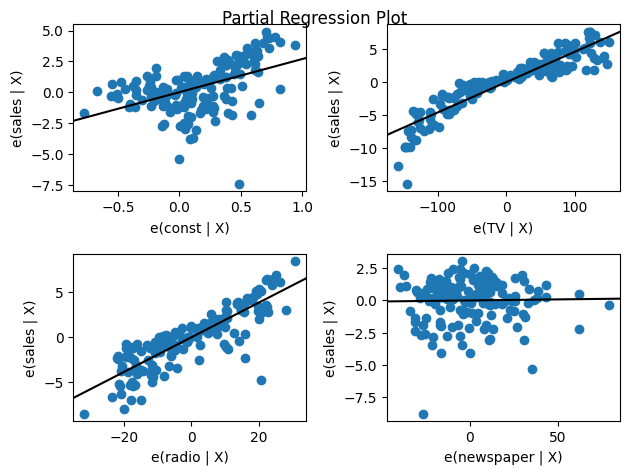

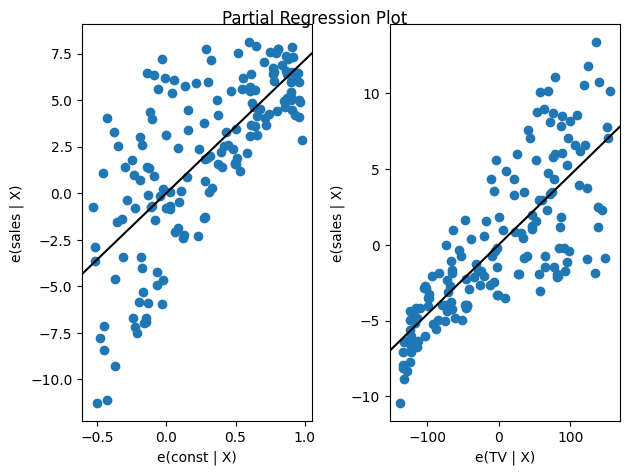

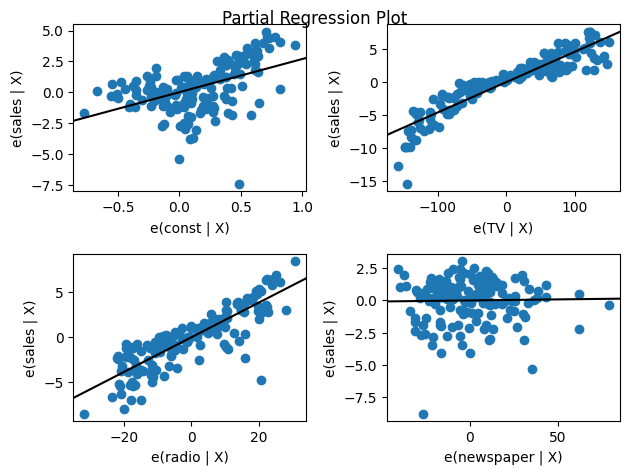

In [6]:
sm.graphics.plot_partregress_grid(tv_lm)
sm.graphics.plot_partregress_grid(mult_lm)




# Exercise 4
### Fit the TV sales into a polynomial regression model with degree=4, print the summary and visualize the model as a plot

R_Squared prediction: 0.585864974542914
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     63.01
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.56e-31
Time:                        21:21:52   Log-Likelihood:                -408.66
No. Observations:                 160   AIC:                             827.3
Df Residuals:                     155   BIC:                             842.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

<Axes: xlabel='TV', ylabel='sales'>

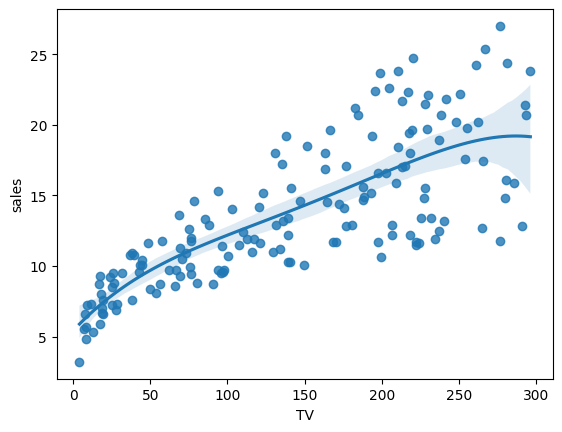

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

tv_poly = PolynomialFeatures(degree=4)
tv_x_train_poly = tv_poly.fit_transform(tv_x_train)
tv_poly_lm = sm.OLS(tv_y_train, tv_x_train_poly).fit()

tv_poly_y_pred = tv_poly_lm.predict(tv_poly.transform(tv_x_test))

rsquared = r2_score(tv_y_test,tv_poly_y_pred )
print(f"R_Squared prediction: {rsquared}" )

print(tv_poly_lm.summary())

sns.regplot(x=tv_x_train[TV], y=tv_y_train, data=sales_data, order=4)


# Exercise 5
### Repeat Exercise 4 with degree=10 and note down your observations.

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                      -0.415
Model:                            OLS   Adj. R-squared:                 -0.452
Method:                 Least Squares   F-statistic:                    -11.37
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               1.00
Time:                        21:21:52   Log-Likelihood:                -513.70
No. Observations:                 160   AIC:                             1037.
Df Residuals:                     155   BIC:                             1053.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.148e-15   5.08e-16      8.165      0.0

<Axes: xlabel='TV', ylabel='sales'>

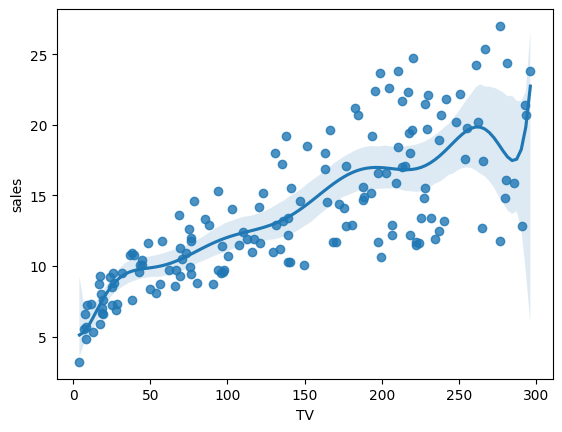

In [8]:
tv_poly = PolynomialFeatures(degree=10)

tv_x_train_poly = tv_poly.fit_transform(tv_x_train)
tv_poly_lm = sm.OLS(tv_y_train, tv_x_train_poly).fit()
print(tv_poly_lm.summary())

sns.regplot(x=tv_x_train[TV], y=tv_y_train, data=sales_data, order=10)

## Code for the PDF exercise:

In [56]:
import numpy as np

In [9]:
#linear
tv_y_pred = tv_lm.predict(tv_x_test)


mse = mean_squared_error(tv_y_test, tv_y_pred)
rmse = mse ** .5

rtwo = r2_score(tv_y_test, tv_y_pred)
rtwo

0.5782001706125217

In [10]:
#polynomal reg., degree = 10

poly_tv_y_pred = tv_poly_lm.predict(tv_poly.fit_transform(tv_x_test))

mse = mean_squared_error(tv_y_test, poly_tv_y_pred)
rmse = mse ** .5

rtwo = r2_score(tv_y_test, poly_tv_y_pred)
rtwo

-0.09194709474657614

### Selbst test:

In [ ]:
X = sales_data[[TV, RADIO, NEWSPAPER]]
Y = sales_data[SALES]



def compare_polys() -> tuple[int, float, float]:

    train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=.2);

    best_degree:int = 1
    best_test_r2:float = 0
    best_train_r2:float =  0
    
    for i in range(1, 10):

        #print(f"Current degree: {i}")

        poly = PolynomialFeatures(i)

        x_poly = poly.fit_transform(train_x)

        lm  = sm.OLS(train_y, x_poly).fit()
        
        train_r2 = lm.rsquared
        #print(train_r2)

        y_predict = lm.predict(poly.transform(test_x))

        test_r2 = r2_score(y_true=test_y, y_pred=y_predict)
        #print(test_r2)


        if test_r2 > best_test_r2:
            best_train_r2 = train_r2
            best_test_r2 = test_r2
            best_degree = i

        

    return best_degree, best_test_r2, best_train_r2
    


degrees: list[int]      = []
test_r2s: list[float]   = []
train_r2s:list[float]   = []


for _ in range(1 , 100):
    d, te, tr = compare_polys()

    degrees.append(d)
    test_r2s.append(te)
    train_r2s.append(tr)

print(degrees)
print(f"Best degree: {np.mean(degrees)}")

#also not a good measurement, as 3 and 5 seem to be good, resulting in a mean of 4




[3, 4, 3, 3, 3, 4, 4, 3, 2, 3, 5, 5, 6, 3, 3, 3, 4, 3, 3, 5, 4, 5, 3, 5, 4, 2, 3, 4, 2, 4, 3, 5, 5, 5, 6, 3, 3, 3, 3, 5, 4, 5, 5, 3, 5, 3, 3, 5, 3, 3, 3, 5, 4, 4, 4, 3, 5, 4, 3, 5, 3, 3, 4, 3, 3, 3, 4, 3, 2, 4, 5, 4, 4, 4, 3, 3, 2, 5, 3, 3, 5, 3, 2, 3, 4, 3, 3, 4, 4, 3, 4, 3, 2, 3, 3, 4, 5, 5, 4]
Best degree: 3.6666666666666665
